# Assignment 1: Image Classification with Multi-Layer Perceptrons

    **Cai Haochen | Student ID 58561440 | EE5438 | Semester A 2026-2027**

    The frozen final classifier obtains **94.04% test accuracy**, macro precision **0.9402**, macro recall **0.9404**, and macro F1 **0.9403** on 10,000 Fashion-MNIST test images. All components are MLPs. No convolution, attention, Transformer, outside training images or pretrained weights are used.

    The technical summary and limitations at the end explain which changes helped, which did not, and the full inference cost. Accuracy meets the assignment's highest published accuracy threshold when at least 93%; marks and top-ten bonus are determined by the instructor, not guaranteed by this notebook.

## 1. Reproducibility and data discipline

    **Run All performs real evaluation of the frozen weights.** The portable bundle below contains readable Python sources, configuration files, recorded training histories, and the selected checkpoints. It is unpacked into a new temporary working directory, leaving existing files untouched. The bundle is not a remote dependency.

    Set `RETRAIN_ALL=True` to rerun the full training sequence from scratch before validation selection and test evaluation. This is deliberately opt-in because it includes all negative-result experiments. Recorded training histories are labelled as recorded evidence; they are not represented as newly executed training in the default evaluation run. PyTorch 2.10, torchvision 0.25, NumPy, pandas, scikit-learn and matplotlib are required. CUDA is recommended; CPU evaluation is supported but slower.

    The official 60,000-image training set is stratified into 54,000 training and 6,000 validation examples, 600 per validation class, using seed **58561440**. Mean and standard deviation come only from the 54,000 training images. Validation chooses checkpoints, averaging, pruning and inference views. The test recipe is frozen and checkpoint hashes are checked before loading test labels. Re-evaluating this frozen recipe is verification, not additional test-driven tuning. The official test set is a public benchmark, not a claim of an independently blinded holdout.

In [1]:
import base64, io, os, sys, tempfile, zipfile
from pathlib import Path
RETRAIN_ALL = False
runtime = Path(tempfile.mkdtemp(prefix='ee5438_assignment1_'))
bundle = base64.b64decode('...')
with zipfile.ZipFile(io.BytesIO(bundle)) as archive:
    assert all(not Path(n).is_absolute() and '..' not in Path(n).parts for n in archive.namelist())
    archive.extractall(runtime)
os.chdir(runtime)
sys.path.insert(0, str(runtime))
print('Self-contained workspace:', runtime)

Self-contained workspace: /tmp/ee5438_assignment1_w09khpr6


In [2]:
import json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torchvision
from torchvision.datasets import FashionMNIST
from IPython.display import display
print({'Python':platform.python_version(), 'PyTorch':torch.__version__,
       'torchvision':torchvision.__version__, 'CUDA':torch.cuda.is_available()})

{'Python': '3.12.11', 'PyTorch': '2.10.0+cu128', 'torchvision': '0.25.0+cu128', 'CUDA': True}


## 2. Architecture and implementation

    The reference MLP is `784 -> 128 -> 64 -> 10`, with sigmoid hidden activations and SGD (learning rate 0.001, batch size 128, 50 epochs). Its low score reflects an undertrained fixed reference recipe, not an optimized SGD ceiling. Cross-entropy consumes raw logits; softmax is applied when probabilities are needed.

    Residual variants use a 784-to-256 input projection, three pre-normalized residual blocks, a final LayerNorm and a ten-class head. Blocks compare GELU, SiLU and approximately parameter-matched SwiGLU. BatchNorm replaces block LayerNorm in its explicit control, while the final LayerNorm remains.

    The dense Mixer reshapes a 28x28 image into 49 non-overlapping 4x4 patches, embeds each with a Linear layer, and alternates token and channel MLPs. Six blocks use width 128; the student uses width 64 and three blocks. Token mixing is shared across channels and channel mixing across tokens. LayerNorm, residual additions, GELU and mean pooling complete this MLP-only design. There is no convolutional patch embedding or attention.

In [3]:
import torch
from torch import nn

class ResidualBlock(nn.Module):
    def __init__(self,width,activation,norm,dropout):
        super().__init__()
        normalizer=nn.LayerNorm if norm=='layer' else nn.BatchNorm1d
        act={'gelu':nn.GELU,'silu':nn.SiLU,'relu':nn.ReLU,'swiglu':nn.SiLU}[activation]
        self.norm=normalizer(width)
        hidden=round(4*width/3) if activation=='swiglu' else 2*width
        self.fc1=nn.Linear(width,hidden)
        self.gate=nn.Linear(width,hidden) if activation=='swiglu' else None
        self.act=act()
        self.drop=nn.Dropout(dropout)
        self.fc2=nn.Linear(hidden,width)

    def forward(self,x):
        normalized=self.norm(x)
        hidden=self.act(self.fc1(normalized))
        if self.gate is not None:
            hidden=hidden*self.gate(normalized)
        return x+self.fc2(self.drop(hidden))

class ResidualMLP(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        width=cfg['width']
        self.embed=nn.Linear(784,width)
        self.blocks=nn.Sequential(*[ResidualBlock(width,cfg['activation'],cfg['norm'],cfg['dropout']) for _ in range(cfg['depth'])])
        self.norm=nn.LayerNorm(width)
        self.head=nn.Linear(width,10)

    def forward(self,x):
        return self.head(self.norm(self.blocks(self.embed(x.flatten(1)))))

class MixerBlock(nn.Module):
    def __init__(self,tokens,width,hidden,dropout):
        super().__init__()
        self.token_norm=nn.LayerNorm(width)
        self.token=nn.Sequential(nn.Linear(tokens,128),nn.GELU(),nn.Dropout(dropout),nn.Linear(128,tokens))
        self.channel_norm=nn.LayerNorm(width)
        self.channel=nn.Sequential(nn.Linear(width,hidden),nn.GELU(),nn.Dropout(dropout),nn.Linear(hidden,width))

    def forward(self,x):
        x=x+self.token(self.token_norm(x).transpose(1,2)).transpose(1,2)
        return x+self.channel(self.channel_norm(x))

class MLPMixer(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.patch=cfg.get('patch',4)
        assert 28%self.patch==0
        width=cfg['width']; tokens=(28//self.patch)**2
        self.embed=nn.Linear(self.patch**2,width)
        hidden=cfg.get('channel_hidden',2*width)
        self.blocks=nn.Sequential(*[MixerBlock(tokens,width,hidden,cfg['dropout']) for _ in range(cfg['depth'])])
        self.norm=nn.LayerNorm(width)
        self.head=nn.Linear(width,10)

    def forward(self,x):
        n=len(x); p=self.patch; side=28//p
        x=x.reshape(n,1,side,p,side,p).permute(0,2,4,1,3,5).reshape(n,side*side,p*p)
        return self.head(self.norm(self.blocks(self.embed(x))).mean(1))

### Training code

    The following cell defines the executable training implementation. Five-epoch linear warmup precedes cosine learning-rate decay to 1% of the peak. AdamW excludes biases and normalization gains from decay. Muon receives only two-dimensional hidden-block matrices; the embedding, classifier, bias and normalization parameters remain on AdamW. Muon uses momentum 0.95, five Newton-Schulz steps and RMS-matched update scaling.

    Geometry uses horizontal flips, rotations within 8 degrees, scale variation within 8%, and translations within two pixels. Raw-image padding is zero. Mixup uses alpha 0.2 and soft targets. Training accuracy under augmentation/Mixup is not directly comparable to clean validation accuracy. Mixer training uses optional CUDA BF16 autocast; parameter storage and optimizer states remain FP32. SAM/ASAM use two gradient evaluations per update; their dropout masks are independent. ASAM uses weight scale `abs(weight)+0.01` for matrices.

In [4]:
"""Training-only fitting and validation selection for the assignment experiments."""
import argparse
import json
import math
import random
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torchvision.datasets import FashionMNIST
from sklearn.model_selection import train_test_split

SEED = 58561440
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT = Path('results')
torch.set_num_threads(4)

def seed_all():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def load_data():
    data = FashionMNIST('data', train=True, download=True)
    train_ids, val_ids = train_test_split(np.arange(len(data)), test_size=6000,
                                        stratify=data.targets.numpy(), random_state=SEED)
    assert not set(train_ids) & set(val_ids)
    assert np.array_equal(np.bincount(data.targets[val_ids]), np.full(10, 600))
    x = data.data.unsqueeze(1).float() / 255
    mean, std = x[train_ids].mean().item(), x[train_ids].std().item()
    return (x[train_ids].to(DEVICE), data.targets[train_ids].to(DEVICE),
            x[val_ids].to(DEVICE), data.targets[val_ids].to(DEVICE), mean, std)

class Model(nn.Module):
    def __init__(self, cfg, mean, std):
        super().__init__()
        self.mean, self.std = mean, std
        self.bf16=cfg.get('bf16',False)
        if cfg['model']=='baseline':
            self.net = nn.Sequential(nn.Flatten(), nn.Linear(784,128), nn.Sigmoid(),
                                     nn.Linear(128,64), nn.Sigmoid(), nn.Linear(64,10))
        else:
            from models import ResidualMLP,MLPMixer
            self.net = MLPMixer(cfg) if cfg['model']=='mixer' else ResidualMLP(cfg)

    def forward(self, x):
        with torch.autocast(device_type=x.device.type,dtype=torch.bfloat16,enabled=self.bf16 and x.is_cuda):
            return self.net((x-self.mean)/self.std).float()

def model_cost(model):
    cost = [0]
    def count(layer, inputs, output):
        cost[0] += output.numel() * layer.in_features
    hooks = [m.register_forward_hook(count) for m in model.modules() if isinstance(m, nn.Linear)]
    model.eval()
    with torch.no_grad():
        model(torch.zeros(1,1,28,28,device=DEVICE))
    for hook in hooks:
        hook.remove()
    return sum(p.numel() for p in model.parameters()), cost[0]

def augment(x):
    n=len(x)
    angle=(torch.rand(n,device=x.device)*2-1)*math.pi*8/180
    scale=1+(torch.rand(n,device=x.device)*2-1)*.08
    flip=torch.where(torch.rand(n,device=x.device)<.5,-1.,1.)
    theta=torch.zeros(n,2,3,device=x.device)
    theta[:,0,0]=angle.cos()*scale*flip; theta[:,0,1]=-angle.sin()*scale
    theta[:,1,0]=angle.sin()*scale*flip; theta[:,1,1]=angle.cos()*scale
    theta[:,:,2]=(torch.rand(n,2,device=x.device)*2-1)*(4/28)
    return F.grid_sample(x,F.affine_grid(theta,x.shape,align_corners=False),align_corners=False)

@torch.no_grad()
def evaluate(model, x, y):
    model.eval()
    logits = torch.cat([model(b).float() for b in x.split(128)])
    return F.cross_entropy(logits, y).item(), (logits.argmax(1)==y).float().mean().item()

def run(cfg):
    OUT.mkdir(exist_ok=True)
    seed_all()
    x,y,vx,vy,mean,std = load_data()
    model = Model(cfg,mean,std).to(DEVICE)
    if cfg.get('init'):
        initial=torch.load(OUT/f"{cfg['init']}.pt",map_location=DEVICE,weights_only=True)
        assert abs(initial['mean']-mean)<1e-7 and abs(initial['std']-std)<1e-7
        model.load_state_dict(initial['state_dict'])
        del initial
    params,macs = model_cost(model)
    teacher=None
    teacher_params=teacher_macs=0
    if cfg.get('teacher'):
        checkpoint=torch.load(OUT/f"{cfg['teacher']}.pt",map_location=DEVICE,weights_only=True)
        # Keep teacher construction from changing the student's random-number stream.
        with torch.random.fork_rng(devices=[torch.cuda.current_device()] if DEVICE.type=='cuda' else []):
            teacher=Model(checkpoint['config'],checkpoint['mean'],checkpoint['std']).to(DEVICE)
        teacher.load_state_dict(checkpoint['state_dict'])
        teacher.requires_grad_(False).eval()
        teacher_params,teacher_macs=model_cost(teacher)
        del checkpoint
        assert not cfg.get('sam'), 'Distillation and SAM are separate controlled trials.'
    hidden=[p for name,p in model.named_parameters() if '.blocks.' in name and p.ndim==2] if cfg.get('optimizer')=='muon' else []
    hidden_ids={id(p) for p in hidden}
    other=[p for p in model.parameters() if id(p) not in hidden_ids]
    optimizers=[torch.optim.AdamW([
        {'params':[p for p in other if p.ndim>1],'weight_decay':cfg['decay']},
        {'params':[p for p in other if p.ndim<=1],'weight_decay':0.0}],lr=cfg['lr'])]
    if hidden:
        optimizers.append(torch.optim.Muon(hidden,lr=cfg['lr'],weight_decay=cfg['decay'],
                                          adjust_lr_fn='match_rms_adamw',momentum=.95,ns_steps=5))
    grouped=[p for opt in optimizers for g in opt.param_groups for p in g['params']]
    assert len(grouped)==len({id(p) for p in grouped})==len(list(model.parameters()))
    best = (-1.,-float('inf'))
    history = []
    averages={}
    if cfg.get('averages'):
        from torch.optim.swa_utils import AveragedModel,get_ema_multi_avg_fn
        assert not any(isinstance(m,nn.BatchNorm1d) for m in model.modules())
        averages={'ema':AveragedModel(model,multi_avg_fn=get_ema_multi_avg_fn(.995)),
                  'swa':AveragedModel(model)}
    average_best={key:(-1.,-float('inf')) for key in averages}
    average_history={key:[] for key in averages}
    average_epochs={}
    started = time.perf_counter()
    for epoch in range(1,cfg['epochs']+1):
        model.train()
        lr = cfg['lr']
        if cfg.get('schedule'):
            lr *= epoch/5 if epoch<=5 else .01+.99*(1+math.cos(math.pi*(epoch-5)/(cfg['epochs']-5)))/2
        for optimizer in optimizers:
            for group in optimizer.param_groups:
                group['lr']=lr
        total_loss = torch.zeros((),device=DEVICE)
        correct = torch.zeros((),device=DEVICE)
        for ids in torch.randperm(len(x),device=DEVICE).split(128):
            images,labels=x[ids],y[ids]
            if cfg.get('augmentation'):
                images=augment(images)
            targets=F.one_hot(labels,10).float()
            smoothing=cfg.get('label_smoothing',0.)
            targets=targets*(1-smoothing)+smoothing/10
            if cfg.get('mixup',0)>0:
                lam=float(np.random.beta(cfg['mixup'],cfg['mixup']))
                perm=torch.randperm(len(ids),device=DEVICE)
                images=lam*images+(1-lam)*images[perm]
                targets=lam*targets+(1-lam)*targets[perm]
            model.zero_grad(set_to_none=True)
            logits=model(images); loss=F.cross_entropy(logits,targets)
            if teacher is not None:
                temperature=cfg['temperature']
                with torch.no_grad():
                    teacher_prob=F.softmax(teacher(images)/temperature,dim=1)
                kl=F.kl_div(F.log_softmax(logits/temperature,dim=1),teacher_prob,reduction='batchmean')*temperature**2
                loss=(1-cfg['distill_alpha'])*loss+cfg['distill_alpha']*kl
            loss.backward()
            if cfg.get('sam'):
                from sharpness import perturb,restore
                assert cfg['norm']=='layer', 'SAM trials require LayerNorm to avoid updating BatchNorm statistics twice.'
                saved=perturb(model,cfg['rho'],cfg['sam']=='asam')
                model.zero_grad(set_to_none=True)
                try:
                    F.cross_entropy(model(images),targets).backward()
                finally:
                    restore(saved)
            for optimizer in optimizers:
                optimizer.step()
            if averages:
                averages['ema'].update_parameters(model)
            total_loss += loss.detach()*len(ids)
            correct += (logits.argmax(1)==y[ids]).sum()
        val_loss,val_acc = evaluate(model,vx,vy)
        if averages and epoch>math.floor(.8*cfg['epochs']):
            averages['swa'].update_parameters(model)
        for key,average in averages.items():
            if int(average.n_averaged)==0:
                continue
            av_loss,av_acc=evaluate(average,vx,vy)
            average_history[key].append(dict(epoch=epoch,val_loss=av_loss,val_accuracy=av_acc))
            if (av_acc,-av_loss)>average_best[key]:
                average_best[key]=(av_acc,-av_loss)
                average_epochs[key]=epoch
                torch.save(dict(state_dict=average.module.state_dict(),config=cfg,mean=mean,std=std),OUT/f"{cfg['name']}_{key}.pt")
        row=dict(epoch=epoch,train_loss=total_loss.item()/len(x),train_accuracy=correct.item()/len(x),
                 val_loss=val_loss,val_accuracy=val_acc,lr=lr,seconds=time.perf_counter()-started)
        history.append(row)
        if (val_acc,-val_loss)>best:
            best=(val_acc,-val_loss)
            best_epoch=epoch
            torch.save(dict(state_dict=model.state_dict(),config=cfg,mean=mean,std=std),OUT/f"{cfg['name']}.pt")
        result=dict(config=cfg,seed=SEED,parameters=params,macs=macs,best_epoch=best_epoch,
                    val_accuracy=best[0],val_loss=-best[1],history=history,
                    seconds=time.perf_counter()-started,complete=epoch==cfg['epochs'])
        result['gradient_evaluations']=epoch*math.ceil(len(x)/128)*(2 if cfg.get('sam') else 1)
        if teacher is not None:
            result.update(teacher_parameters=teacher_params,teacher_macs=teacher_macs,
                          teacher_training_cost_included=False,teacher_forward_passes=epoch*len(x))
        (OUT/f"{cfg['name']}.json").write_text(json.dumps(result,indent=2))
        if epoch==1 or epoch%20==0 or epoch==cfg['epochs']:
            print(cfg['name'],row,flush=True)
    result['completed_at']=datetime.now(timezone.utc).isoformat()
    (OUT/f"{cfg['name']}.json").write_text(json.dumps(result,indent=2))
    with Path('JOURNAL.md').open('a') as journal:
        journal.write(f"\n## {result['completed_at']} — {cfg['name']}\n\n"
                      f"Hypothesis: {cfg['hypothesis']}\n\n"
                      f"Measured validation accuracy: {best[0]:.2%}; checkpoint epoch {best_epoch}; "
                      f"{params:,} parameters; {macs:,} dense MACs/image; {result['seconds']:.1f}s training/validation wall time. "
                      f"Configuration and every epoch: `results/{cfg['name']}.json`. Test set not evaluated.\n")
    for key in averages:
        averaged=dict(result,history=average_history[key],val_accuracy=average_best[key][0],
                      val_loss=-average_best[key][1],best_epoch=average_epochs[key],
                      averaging=key,shared_training_run=cfg['name'])
        (OUT/f"{cfg['name']}_{key}.json").write_text(json.dumps(averaged,indent=2))
        with Path('JOURNAL.md').open('a') as journal:
            journal.write(f"\n### {result['completed_at']} - {cfg['name']} {key.upper()}\n\n"
                          f"Validation accuracy {averaged['val_accuracy']:.2%} at epoch {averaged['best_epoch']}. "
                          f"Same training trajectory as the ordinary checkpoint; training cost is shared, not an independent run. "
                          f"EMA decay 0.995 after each batch; SWA snapshots at each epoch in the final 20%. "
                          f"LayerNorm needs no BatchNorm recalibration. Evidence: `results/{cfg['name']}_{key}.json`.\n")
    return result

In [5]:
"""SAM/ASAM perturbation with exact weight restoration before the base update."""
import torch

@torch.no_grad()
def perturb(model,rho,adaptive=False):
    params=[p for p in model.parameters() if p.grad is not None]
    scales=[p.abs()+.01 if adaptive and p.ndim>1 else torch.ones_like(p) for p in params]
    norm=torch.stack([(s*p.grad).norm() for p,s in zip(params,scales)]).norm().clamp_min(1e-12)
    original=[p.detach().clone() for p in params]
    for p,s in zip(params,scales):
        p.add_(s.square()*p.grad*(rho/norm))
    return list(zip(params,original))

@torch.no_grad()
def restore(saved):
    for parameter,value in saved:
        parameter.copy_(value)

### Optional full training

    The student distillation loss is `(1-alpha)*CE + alpha*T^2*KL(teacher || student)`, with alpha 0.5 and temperature 3. The teacher is the independently trained, frozen AdamW Mixer; only training images are used for teacher targets. Teacher construction preserves the student's random-number stream. Its paired control uses the same student initialization and training configuration. Teacher pretraining and forward passes are additional training costs, even though student inference needs only the student.

    EMA decay is 0.995 after each minibatch. SWA averages epoch snapshots in the final 20% of one fine-tuning trajectory. Both use native PyTorch averaging and LayerNorm, so no BatchNorm recalibration is needed. Structured pruning removes channel-MLP neurons ranked by the product of incoming and outgoing weight norms. It removes rows/biases from the first matrix and matching columns from the second matrix, reducing physical dimensions; it is not masked dense inference.

In [6]:
if RETRAIN_ALL:
    import runpy
    runpy.run_path('baseline.py', run_name='__main__')
    from train import run
    sequence = ['adamw','residual_gelu','residual_silu','residual_bn','geometry','mixup',
                'swiglu','muon','sam','asam','mixer','mixer_muon','averages',
                'student_control','student_distill']
    for name in sequence:
        run(json.loads(Path(f'configs/{name}.json').read_text()))
    from prune import trials
    trials()
    for name in ['regularization_none','regularization_dropout','regularization_decay']:
        run(json.loads(Path(f'configs/{name}.json').read_text()))
    from select_final import select
    select()
else:
    print('Using recorded training evidence and frozen checkpoints; full retraining is disabled.')

Using recorded training evidence and frozen checkpoints; full retraining is disabled.


## 3. Recorded experiments and validation analysis

In [7]:
records = {p.stem:json.loads(p.read_text()) for p in Path('results').glob('*.json')}
rows=[]
for name,r in records.items():
    if 'val_accuracy' not in r: continue
    cfg=r.get('config',{})
    rows.append({'experiment':name,'val_accuracy_%':100*r['val_accuracy'],
                 'parameters':r.get('parameters',109386),'dense_MACs':r.get('macs',109184),
                 'epochs':cfg.get('epochs',50),'best_epoch':r.get('best_epoch'),
                 'seconds':r.get('seconds'),'averaging':r.get('averaging',''),
                 'shared_training_run':r.get('shared_training_run','')})
table=pd.DataFrame(rows).sort_values('val_accuracy_%',ascending=False)
display(table.round({'val_accuracy_%':3,'seconds':2}))

,experiment,val_accuracy_%,parameters,dense_MACs,epochs,best_epoch,seconds,averaging,shared_training_run
8,mixer_average_ema,94.017,478640,29003008,30,4.0,50.18,ema,mixer_average
0,mixer_average,93.883,478640,29003008,30,4.0,50.18,,
6,mixer_muon,93.883,478640,29003008,120,82.0,346.36,,
12,mixer_pruned_75,93.700,379952,24186112,25,4.0,37.02,,
4,mixer_adamw,93.683,478640,29003008,120,86.0,194.55,,
2,mixer_average_swa,93.667,478640,29003008,30,26.0,50.18,swa,mixer_average
23,mixer_pruned_50,93.467,281264,19369216,25,12.0,38.27,,
16,student_control,92.317,90525,4867712,80,70.0,71.79,,
18,student_distill,92.317,90525,4867712,80,77.0,103.22,,
20,mixer_pruned_75_initial,91.467,379952,24186112,25,NaN,NaN,,


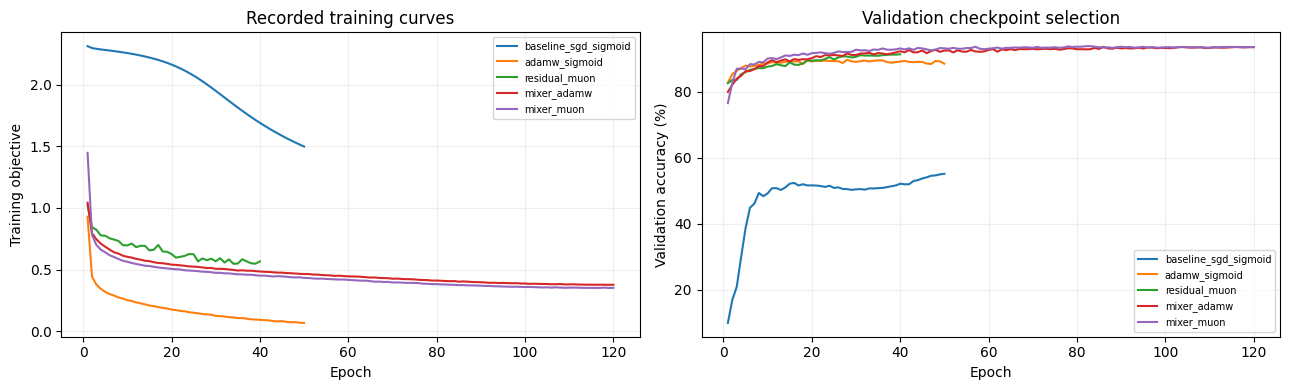

In [8]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
for name in ['baseline_sgd_sigmoid','adamw_sigmoid','residual_muon','mixer_adamw','mixer_muon']:
    history=records[name]['history']
    epochs=[r['epoch'] for r in history]
    axes[0].plot(epochs,[r['train_loss'] for r in history],label=name)
    axes[1].plot(epochs,[100*r['val_accuracy'] for r in history],label=name)
axes[0].set(xlabel='Epoch',ylabel='Training objective',title='Recorded training curves')
axes[1].set(xlabel='Epoch',ylabel='Validation accuracy (%)',title='Validation checkpoint selection')
for ax in axes: ax.grid(alpha=.2); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

Training objectives differ across smoothed-label, Mixup and ordinary cross-entropy runs; their loss magnitudes are not controlled comparisons. More epochs and BF16 distinguish the Mixer recipe from the earlier residual recipe. Ordinary, EMA and SWA entries share one fine-tuning run; do not sum their wall times as independent experiments.

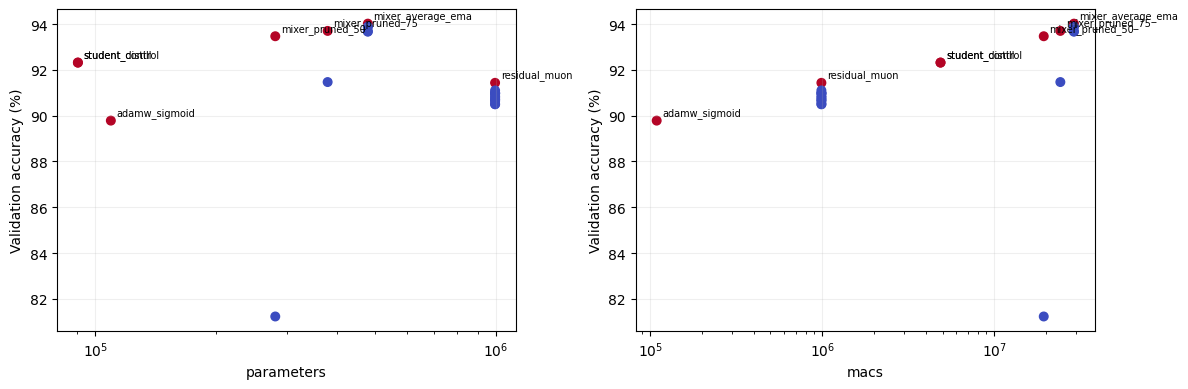

,name,parameters,macs,val_accuracy,best_epoch,seconds,shared_run,pareto
0,adamw_sigmoid,109386,109184,0.897833,28.0,8.265554,NaN,True
18,residual_muon,994056,988928,0.914333,40.0,42.599556,NaN,True
22,student_control,90525,4867712,0.923167,70.0,71.785248,NaN,True
23,student_distill,90525,4867712,0.923167,77.0,103.224182,NaN,True
6,mixer_pruned_50,281264,19369216,0.934667,12.0,38.270650,NaN,True
8,mixer_pruned_75,379952,24186112,0.937000,4.0,37.023065,NaN,True
3,mixer_average_ema,478640,29003008,0.940167,4.0,50.177990,mixer_average,True


In [9]:
pareto=pd.read_csv('results/pareto.csv')
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,cost in zip(axes,['parameters','macs']):
    ax.scatter(pareto[cost],100*pareto.val_accuracy,c=pareto.pareto.astype(int),cmap='coolwarm',s=38)
    for _,row in pareto[pareto.pareto].iterrows():
        ax.annotate(row['name'],(row[cost],100*row.val_accuracy),fontsize=7,xytext=(4,4),textcoords='offset points')
    ax.set_xscale('log'); ax.set_xlabel(cost); ax.set_ylabel('Validation accuracy (%)'); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()
display(pareto[pareto.pareto].sort_values('macs'))

Pareto dominance is defined jointly over validation accuracy (higher), physical parameters (lower) and dense MACs (lower). A model with fewer parameters is not necessarily cheaper: Mixer weights are reused over tokens. FLOPs are approximately twice dense MACs, excluding nonlinearities, normalization, memory traffic and augmentation. This chart describes single-model, single-view checkpoints, not ensemble cost.

## 4. Frozen final evaluation

    Candidate search is bounded in advance: evaluate 1/2/4-view inference only for models within 1.5 percentage points of the best recorded raw validation score; then try equal-weight pairs/triples from the four best distinct checkpoints. Views are identity, horizontal flip, and optionally one-pixel zero-padded left/right shifts. Select highest validation correct count, breaking ties by lower total MACs, then fewer stored parameters, then lower negative log-likelihood. This is validation-based model selection, not evidence that every inference view is independently beneficial.

In [10]:
recipe=json.loads(Path('results/final_recipe.json').read_text())
display(pd.DataFrame(recipe['components']))
print({k:recipe[k] for k in ['frozen_at','accuracy','correct','examples','parameters','macs','candidates']})
from evaluate_final import evaluate_final
test=evaluate_final()
if not RETRAIN_ALL:
    assert abs(test['accuracy']-0.9404) <= 0.0002
display(pd.DataFrame(test['classification_report']).T.round(4))

,name,views,sha256
0,mixer_average,4,fae83cad3cc65dc5f589bc10e5fc08c4fd537471ce9b20...
1,mixer_average_swa,4,37d428908c9540e3d4f92fd19f4cd76937fea7bd55369a...
2,mixer_muon,4,bdbf5994d63c23cdf4d6b059c625e4710f3a533e7992ad...


{'frozen_at': '2026-09-18T08:28:40.312871+00:00', 'accuracy': 0.9466666666666667, 'correct': 5680, 'examples': 6000, 'parameters': 1435920, 'macs': 348036096, 'candidates': 31}


  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<02:49, 156kB/s]

  0%|          | 65.5k/26.4M [00:00<02:48, 157kB/s]

...

100%|██████████| 4.42M/4.42M [00:01<00:00, 2.59MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 41.7MB/s]

{
  "correct": 9404,
  "examples": 10000,
  "accuracy": 0.9404,
  "loss": 0.18693450093269348,
  "macro_precision": 0.9402131553219191,
  "macro_recall": 0.9404,
  "macro_f1": 0.9402611527151142,
  "weighted_f1": 0.9402611527151145,
  "accuracy_ci95_wilson": [
    0.935588503154088,
    0.9448732586554951
  ],
  "parameters": 1435920,
  "macs": 348036096,
  "recipe": "mixer_average:4 + mixer_average_swa:4 + mixer_muon:4",
  "recipe_frozen_at": "2026-09-18T08:28:40.312871+00:00",
  "evaluated_at": "2026-09-18T08:30:31.806528+00:00",
  "baseline": {
    "correct": 5459,
    "examples": 10000,
    "accuracy": 0.5459,
    "loss": 1.492736577987671
  },
  "environment": {
    "python": "3.12.11",
    "torch": "2.10.0+cu128",
    "torchvision": "0.25.0+cu128",
    "device": "NVIDIA GeForce RTX 5090"
  }
}


,precision,recall,f1-score,support
T-shirt/top,0.8915,0.8960,0.8938,1000.0000
Trouser,0.9970,0.9880,0.9925,1000.0000
Pullover,0.9148,0.9130,0.9139,1000.0000
Dress,0.9386,0.9470,0.9428,1000.0000
Coat,0.9022,0.9220,0.9120,1000.0000
Sandal,0.9890,0.9850,0.9870,1000.0000
Shirt,0.8357,0.8090,0.8222,1000.0000
Sneaker,0.9656,0.9810,0.9732,1000.0000
Bag,0.9920,0.9950,0.9935,1000.0000
Ankle boot,0.9758,0.9680,0.9719,1000.0000


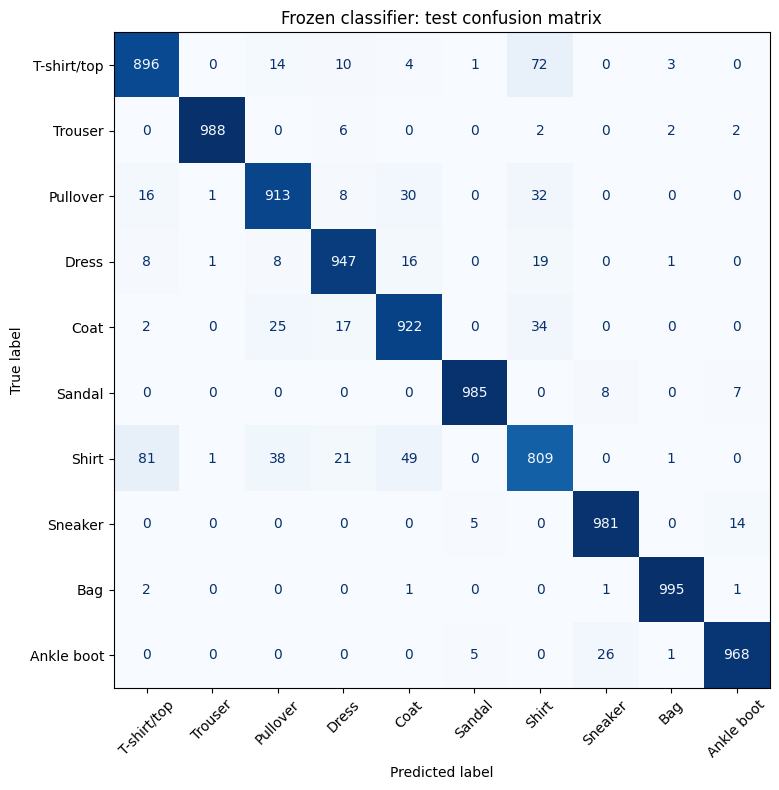

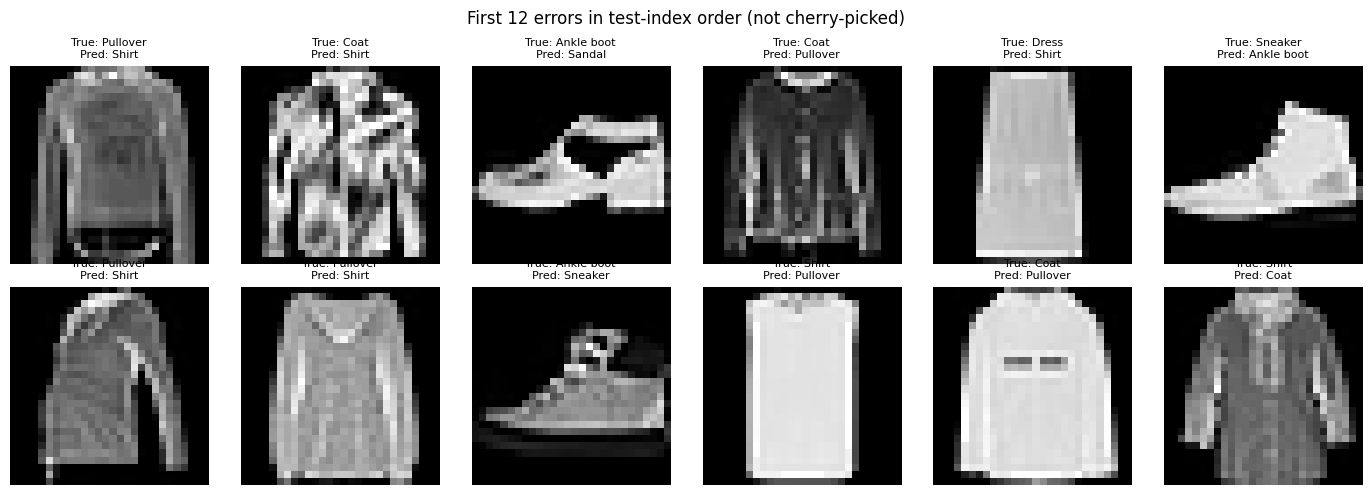

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
test_data=FashionMNIST('data',train=False,download=True)
fig,ax=plt.subplots(figsize=(9,8))
ConfusionMatrixDisplay(np.asarray(test['confusion_matrix']),display_labels=test_data.classes).plot(ax=ax,cmap='Blues',colorbar=False,xticks_rotation=45)
ax.set_title('Frozen classifier: test confusion matrix'); plt.tight_layout(); plt.show()
predictions=np.load('results/final_test_predictions.npz')
labels=predictions['labels']; predicted=predictions['probabilities'].argmax(1)
errors=np.flatnonzero(predicted!=labels)[:12]
fig,axes=plt.subplots(2,6,figsize=(14,5))
for ax,idx in zip(axes.flat,errors):
    ax.imshow(test_data.data[idx],cmap='gray'); ax.axis('off')
    ax.set_title(f'True: {test_data.classes[labels[idx]]}\nPred: {test_data.classes[predicted[idx]]}',fontsize=8)
plt.suptitle('First 12 errors in test-index order (not cherry-picked)'); plt.tight_layout(); plt.show()

The lowest class F1 is **Shirt: 0.8222**. The largest directed confusions are **Shirt -> T-shirt/top: 81 images**; **T-shirt/top -> Shirt: 72 images**; **Shirt -> Coat: 49 images**. These results describe the frozen classifier; they are not used to introduce another model change. Similar garment silhouettes remain a challenge at 28x28 resolution.

## 5. Technical summary and conclusions

    ### What improved

    The fixed sigmoid/SGD baseline reaches 55.22% validation accuracy. Changing only its optimizer to AdamW reaches 89.78%, indicating that optimization and the small SGD learning rate strongly limit the reference run. The wider residual GELU recipe reaches 90.97%; it changes architecture, normalization, regularization and scheduling together, so this is not an isolated causal estimate of skip connections.

    Matched residual comparisons yield SiLU 90.80%, BatchNorm 90.85%, geometry 90.98%, and Mixup 90.50%. Mixup does not help this GELU configuration at the tested alpha and budget. Approximately parameter-matched SwiGLU reaches 91.10%; Muon/AdamW reaches 91.43%. SAM 90.62% and ASAM 90.50% do not improve that baseline, despite twice the gradient evaluations. These are negative results for the tested settings, not universal method rankings.

    The matched Mixer comparison gives AdamW 93.68% and Muon/AdamW 93.88%. Their observed training/validation times are 194.5s and 346.4s on the shared GPU. Muon offers a small accuracy gain here, not a twofold speed-up. Its language-model scaling results cannot be transferred to this workload. Parameter grouping is important: only hidden matrices use Muon.

    Clean fine-tuning gives ordinary weights 93.88%, EMA 94.02% and SWA 93.67%. Late clean-training accuracy approaches 100% while validation loss grows; checkpoint selection and EMA limit this overfitting, whereas SWA is not automatically better. The matched small student obtains 92.32% without distillation and 92.32% with distillation, using 90,525 parameters and 4,867,712 dense MACs per image. Distillation adds the teacher's pretraining and forward-pass costs; student-only deployment avoids them.

    The student control and distilled student tie on best validation accuracy. This trial therefore does not demonstrate an accuracy benefit from distillation at the tested setting, despite its additional training cost.

    ### Regularization and model efficiency

    The 2x2 control yields neither dropout nor decay 90.72%, dropout only 90.98%, decay only 90.68%, and both 90.97%. These results describe one fixed architecture and seed; they do not establish a universally optimal regularizer.

    Retaining 75% of channel neurons gives 91.47% before recovery and 93.70% after fine-tuning; retaining 50% gives 81.23% and 93.47%. The compression removes real matrix dimensions and its fine-tuning cost is additional. The Pareto table reports measured accuracy against both parameter and computation cost. Initial pruning damage and recovered accuracy are reported separately.

    ### Final result and cost

    The frozen recipe is **mixer_average:4 + mixer_average_swa:4 + mixer_muon:4**. It obtains **9404/10,000 correct (94.04%)** on the official test split, compared with **54.59%** for the fixed sigmoid/SGD reference. Macro precision is **0.9402**, macro recall **0.9404**, macro F1 **0.9403**, and weighted F1 **0.9403**. The confusion matrix and per-class table identify remaining class-specific errors.

    Deployment requires **1,435,920 total stored parameters** and **348,036,096 dense MACs per image**, approximately **696,072,192 dense FLOPs**. These totals include all ensemble members and every inference view. They must not be presented as the cost of one single-pass model. Averaged weights themselves add no deployment model beyond the resulting checkpoint.

    The two-member SWA/Muon alternative achieves 5,679/6,000 validation correct (94.65%) at 957,280 parameters and 232,024,064 MACs/image. The selected three-member recipe adds only **one validation-correct image**, while increasing both costs by 50%. The prespecified accuracy-first rule chooses it, but this tiny gain is not convincing evidence of a generalization advantage; the two-member alternative is a more economical candidate if deployment cost is prioritized. It was not selected or retuned using test results.

    ### Limits and next steps

    All experiments use one assignment-specific seed and one validation split. Repeated validation selection may overfit that split; architecture comparisons with different budgets and regularizers are recipe comparisons, not clean causal ablations. Shared-device wall time is descriptive, not a controlled hardware benchmark. The descriptive Wilson 95% interval for final test accuracy is [93.56%, 94.49%]; it does not account for adaptive validation search, dataset shift, or prove that small differences are significant. No test result is used for subsequent changes to the frozen classifier. Further research should use independent seeds and a new validation protocol, rather than tuning against this test score.

    Section A is supplied separately as a typed study guide. The assignment requires the student's genuine handwritten or iPad-written answers in one PDF. A typed guide is not a compliant handwritten submission. Review and understand the answers and code, and follow the course's assistance/disclosure rules before submission.

## References


- Assignment: https://eelmpo.github.io/ee5438/pdf/2026_EE5438_Ass01.pdf
- Course slides: https://eelmpo.github.io/ee5438/schedule.html
- Starter notebook: https://colab.research.google.com/drive/1UQYf7m0xGBaqUgnviLBR9rfbmddkUsxq
- Fashion-MNIST: https://github.com/zalandoresearch/fashion-mnist
- Muon parameter-group guidance: https://github.com/KellerJordan/Muon (README checked 2026-09-18).
- Native Muon: https://docs.pytorch.org/docs/stable/generated/torch.optim.Muon.html
- Native parameter averaging: https://docs.pytorch.org/docs/stable/optim.html#weight-averaging-swa-and-ema
- MLP-Mixer architecture: https://arxiv.org/abs/2105.01601
- SAM: https://arxiv.org/abs/2010.01412
- ASAM: https://arxiv.org/abs/2102.11600
- Knowledge distillation: https://arxiv.org/abs/1503.02531

The models are small assignment-specific implementations trained from scratch on the official training split. No pretrained weights or external training examples are used. Native PyTorch implements AdamW, Muon, averaging, loss functions and automatic differentiation; the small SAM/ASAM perturbation helper has a runnable restoration check. This is a single-seed exploratory benchmark, not a statistical replication of the cited papers.

Computational complexity is reported as dense multiply-accumulate operations (MACs) per image. Approximate dense FLOPs = 2 x MACs. Normalization, activations, softmax, augmentation and memory traffic are excluded; parameter counts include biases and normalization gains. Timing is observed wall time on a shared RTX 5090, not a dedicated-device speed claim.